# Missingness and Shortcuts Under Distribution Shift

**Research question.** What happens when an excellent predictor reverses its correlation after deployment?

Original controlled experiment by Zangar. This notebook runs offline and uses synthetic data, never real personal records. [Source and reproduction instructions](https://github.com/zoga228/validation-stress-lab).

AI tools assisted implementation and editing; all reported measurements come from executed code.

## Experimental protocol

All preprocessing is fitted on training data. Compare a linear model with missingness flags and histogram boosting with native missing-value support. Fit each with and without a deliberately unstable shortcut, then evaluate IID and shifted populations across three independent seeds. The test domains are diagnostics; they never participate in training or tuning.

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '2'
os.environ['MKL_NUM_THREADS'] = '2'
import numpy as np, pandas as pd, sklearn, matplotlib
print({'numpy':np.__version__,'pandas':pd.__version__,'sklearn':sklearn.__version__,'matplotlib':matplotlib.__version__})

{'numpy': '2.2.6', 'pandas': '2.3.1', 'sklearn': '1.7.1', 'matplotlib': '3.10.6'}


## Data-generating process

The generator is included so every assumption is inspectable. A downloadable CSV version is attached; the seeds below regenerate the same benchmark without file-path dependencies. Synthetic results illustrate a failure mode and do not establish performance on real data.

In [2]:
"""Original synthetic benchmarks; no real people, records, or competition data."""
import json
from pathlib import Path
import numpy as np
import pandas as pd


def grouped(seed=42, groups=400, repeats=30):
    rng = np.random.default_rng(seed)
    ids = np.repeat(np.arange(groups), repeats)
    latent = rng.integers(0, 2, size=groups)
    flip = rng.random(len(ids)) < .08
    return pd.DataFrame({"group_id": ids.astype(str), "sensor_noise": rng.normal(size=len(ids)), "target": np.logical_xor(latent[ids], flip).astype(int)})


def missingness(seed=42, n=6000, shifted=False):
    rng = np.random.default_rng(seed)
    x = rng.normal(size=(n, 6))
    score = 1.6*x[:, 0] - .8*x[:, 1] + .5*x[:, 2]*x[:, 3]
    y = (rng.random(n) < 1 / (1 + np.exp(-score))).astype(int)
    # An apparent signal reverses at deployment. This is a controlled stress test.
    correlated = (y + rng.normal(0, .4, n)) if not shifted else ((1-y) + rng.normal(0, .4, n))
    missing = rng.random(n) < np.where(y == 1, .3 if not shifted else .7, .1 if not shifted else .4)
    x[missing, 0] = np.nan
    df = pd.DataFrame(x, columns=[f"x{i}" for i in range(6)])
    df["spurious"] = correlated
    df["target"] = y
    return df


def regression(seed=42, n=4000, shifted=False):
    rng = np.random.default_rng(seed)
    x = rng.normal(1.8 if shifted else 0, 1, n)
    sigma = .3 + .4*np.abs(x)
    y = np.sin(2*x) + .5*x + sigma*rng.normal(size=n)
    return pd.DataFrame({"x": x, "target": y})


def export(root):
    root = Path(root)
    specs = {
        "grouped-validation": {"all.csv": grouped()},
        "missingness-shift": {"train.csv": missingness(42), "iid-test.csv": missingness(43, 3000), "shift-test.csv": missingness(44, 3000, True)},
        "conformal-shift": {"train.csv": regression(42), "calibration.csv": regression(43, 2000), "iid-test.csv": regression(44, 3000), "shift-test.csv": regression(45, 3000, True)},
    }
    for name, files in specs.items():
        folder = root / name
        folder.mkdir(parents=True, exist_ok=True)
        for filename, frame in files.items():
            frame.to_csv(folder / filename, index=False)
        info = {"synthetic": True, "license": "CC0-1.0", "generator": "make_data.py", "version": "1.0", "files": {k: {"rows": len(v), "columns": list(v)} for k, v in files.items()}, "purpose": "Controlled experiments about validation assumptions; not evidence about a real population"}
        (folder / "data-card.json").write_text(json.dumps(info, indent=2))
        print(name, info["files"])




## Fit and evaluate

Run the complete analysis. Seeds, model settings, and saved tables are explicit.

                                                 auc  log_loss
model                  features    domain                     
histogram boosting     all         IID      0.976501  0.198096
                                   shifted  0.113430  3.249033
                       stable only IID      0.835939  0.499069
                                   shifted  0.771956  0.594553
linear + missing flags all         IID      0.978550  0.187055
                                   shifted  0.110986  2.876976
                       stable only IID      0.835345  0.498862
                                   shifted  0.774929  0.587873


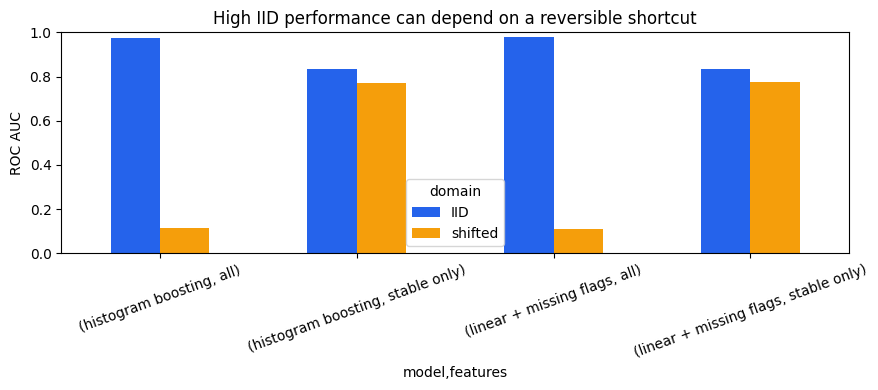

In [3]:
"""Train-only preprocessing and stress testing an unstable shortcut feature."""
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def run():
    rows = []
    for seed in (11, 22, 33):
        train = missingness(seed)
        tests = {"IID": missingness(seed+100, 3000), "shifted": missingness(seed+200, 3000, True)}
        for features in ("all", "stable only"):
            columns = [f"x{i}" for i in range(6)] + (["spurious"] if features == "all" else [])
            models = {
                "linear + missing flags": make_pipeline(SimpleImputer(add_indicator=True), StandardScaler(), LogisticRegression(max_iter=1000)),
                "histogram boosting": HistGradientBoostingClassifier(max_iter=150, max_leaf_nodes=15, l2_regularization=1, random_state=seed),
            }
            for name, model in models.items():
                model.fit(train[columns], train.target)
                for domain, test in tests.items():
                    p = model.predict_proba(test[columns])[:, 1]
                    rows.append({"seed": seed, "model": name, "features": features, "domain": domain, "auc": roc_auc_score(test.target, p), "log_loss": log_loss(test.target, p)})
    result = pd.DataFrame(rows)
    summary = result.groupby(["model", "features", "domain"])[["auc", "log_loss"]].mean()
    print(summary.to_string())
    fig, ax = plt.subplots(figsize=(9, 4))
    pivot = result.groupby(["model", "features", "domain"]).auc.mean().unstack()
    pivot.plot.bar(ax=ax, color=["#2563eb", "#f59e0b"])
    ax.set(ylabel="ROC AUC", ylim=(0, 1), title="High IID performance can depend on a reversible shortcut")
    ax.tick_params(axis="x", rotation=20)
    fig.tight_layout()
    out=Path("outputs");out.mkdir(exist_ok=True)
    result.to_csv(out / "missingness-shift.csv", index=False)
    fig.savefig(out / "missingness-shift.png", dpi=160)
    plt.show()
    return result


results = run()

## Interpretation and limitations

Both models score around 0.977 IID AUC with the shortcut but around 0.11 when it reverses. Stable-only models sacrifice IID performance and retain around 0.77 shifted AUC. This is a designed counterexample, not an estimate of real-world degradation. Removing predictors requires domain justification; a shift detector alone cannot identify the correct causal feature set.

**Reference:** https://scikit-learn.org/stable/modules/ensemble.html#histogram-based-gradient-boosting

Reproduce first, then adapt the protocol to the population and metric of your own task.